In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
from scipy.stats import beta

In [3]:
# Paleta CUNEF
CUNEF_ORANGE  = "#E8500A"
CUNEF_AMBER   = "#F4A261"
CUNEF_CREAM   = "#FAE3D0"
CUNEF_DARK    = "#0D0D0D"
CUNEF_PANEL   = "#141414"
CUNEF_GRAY    = "#6B6B6B"
CUNEF_LGRAY   = "#3A3A3A"

mpl.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "figure.facecolor":   CUNEF_DARK,
    "axes.facecolor":     CUNEF_PANEL,
    "text.color":         "white",
    "axes.labelcolor":    "white",
    "xtick.color":        CUNEF_GRAY,
    "ytick.color":        CUNEF_GRAY,
    "axes.edgecolor":     CUNEF_LGRAY,
    "axes.linewidth":     0.7,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "grid.color":         "#1F1F1F",
    "grid.linewidth":     0.8,
})


In [4]:
# Inicializamos valores de theta entre 0 y 1
theta = np.linspace(0, 1, 1000)

In [5]:
caras = 7
cruces = 3

a_post = 1 + caras
b_post = 1 + cruces

In [6]:
# Distribucion prior antes de ver los datos
prior = beta.pdf(theta, 1, 1)
# Distribucion posteiror despues de ver los datos
posterior = beta.pdf(theta, a_post, b_post)

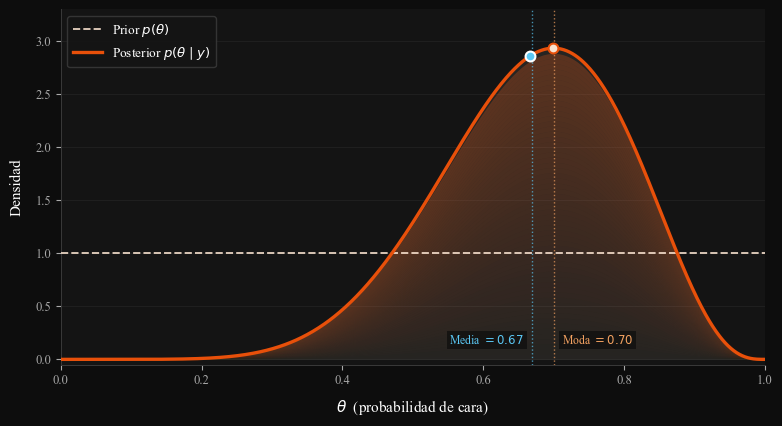

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.8))
fig.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.14)

# Gradiente bajo la posterior
# Degradado vertical simulado con fill_between en capas
n_layers = 60
alphas   = np.linspace(0.0, 0.28, n_layers)
for i in range(n_layers - 1):
    frac = i / n_layers
    ax.fill_between(theta, posterior * frac, posterior * (frac + 1/n_layers),
                    color=CUNEF_ORANGE, alpha=alphas[i], zorder=1, linewidth=0)

# Relleno sólido tenue encima
ax.fill_between(theta, posterior, alpha=0.08,
                color=CUNEF_CREAM, zorder=1, linewidth=0)

# Prior
ax.plot(theta, prior,
        linestyle="--", linewidth=1.4,
        color=CUNEF_CREAM, alpha=0.85,
        label=r"Prior $p(\theta)$", zorder=3)

# Posterior
ax.plot(theta, posterior,
        linestyle="-", linewidth=2.4,
        color=CUNEF_ORANGE,
        label=r"Posterior $p(\theta \mid y)$", zorder=4)

# Punto en el máximo de la posterior (moda)
moda_x = theta[np.argmax(posterior)]
moda_y = posterior.max()
ax.scatter([moda_x], [moda_y], color=CUNEF_CREAM,
           s=50, zorder=6, linewidths=1.5,
           edgecolors=CUNEF_ORANGE)

# Punto en la MEDIA 
media_x = 8 / 12  # = 0.667
media_y = beta.pdf(media_x, 8, 4)

ax.scatter([media_x], [media_y],
           color="#5BC8F5",        # azul claro, igual que su línea
           s=50, zorder=6,
           linewidths=1.5, edgecolors="#FFFFFF")

# Línea vertical: MODA = 0.70
ax.axvline(0.70, color=CUNEF_AMBER, linewidth=1.0,
           linestyle=":", alpha=0.7, zorder=2)

# Línea vertical: MEDIA = 0.67
ax.axvline(0.67, color="#5BC8F5", linewidth=1.0,
           linestyle=":", alpha=0.7, zorder=2)

# Moda: a la derecha de su línea (0.70)
ax.text(0.712, 0.12,
        r"Moda $= 0.70$",
        fontsize=8.5, color=CUNEF_AMBER,
        va="bottom", ha="left",
        bbox=dict(facecolor=CUNEF_DARK, edgecolor="none", alpha=0.7, pad=2))

# Media: a la IZQUIERDA de su línea (0.67) para no chocar con la moda
ax.text(0.658, 0.12,
        r"Media $= 0.67$",
        fontsize=8.5, color="#5BC8F5",
        va="bottom", ha="right",       # ← ha="right" la empuja a la izquierda
        bbox=dict(facecolor=CUNEF_DARK, edgecolor="none", alpha=0.7, pad=2))


# Rejilla
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

# Ejes
ax.set_xlabel(r"$\theta$  (probabilidad de cara)",
              fontsize=11, labelpad=8)
ax.set_ylabel("Densidad", fontsize=11, labelpad=8)
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 3.3)

# Ticks de color blanco suave
ax.tick_params(colors="#AAAAAA", labelsize=9)

# Leyenda
leg = ax.legend(
    frameon=True, framealpha=0.85,
    facecolor=CUNEF_PANEL, edgecolor=CUNEF_LGRAY,
    fontsize=9.5, loc="upper left",
    labelcolor="white",
    handlelength=2.2,
)

plt.savefig("images/prior_vs_posterior.png", dpi=200, bbox_inches="tight")
plt.show()